# 07 — hypothesis C re-run on the pump harvest (n=6)

nb06 tested C (does a causal CVD/price bearish divergence predict reversal?) on
**n=2** (LAB+MAGMA) and found the effect was **LAB-only** — a one-episode
narrative. We now have a live depth-200 harvest with **six real alt pumps** in
one 2.9h session, so we can finally adjudicate:

| sym | 2.9h range |
|---|---|
| EVAA | +28.9% | 
| VELVET | +18.4% |
| US | +18.1% |
| SKL | +16.4% |
| LAB | +9.4% |
| TAC | +8.9% |

Same machinery as nb06 (5s grid; trailing 30s move + CVD-confirmation; forward
30/120s return). **The decider is §2b: does the confirmed>divergence gap hold
the same sign across all 6 symbols, or does it scatter like nb06?** BTC+SOL are
carried as a calm control (should show little).

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

SESS = "2026-07-10T11-31-38Z"        # the live depth-200 harvest
PUMPS = ["EVAAUSDT", "VELVETUSDT", "USUSDT", "SKLUSDT", "LABUSDT", "TACUSDT"]
REF   = ["BTCUSDT", "SOLUSDT"]
GRID, W = "5s", 6

def build(sym):
    ob = load(SESS, "orderbook", sym, with_datetime=True)
    tr = load(SESS, "trades", sym, with_datetime=True)
    m = mid(ob).resample(GRID).last().ffill()
    sgn = np.where(tr["side"] == "buy", 1.0, -1.0)
    cvd = pd.Series(sgn * tr["amount"].to_numpy(), index=tr.index).cumsum()
    c = cvd.resample(GRID).last().ffill()
    df = pd.DataFrame({"mid": m, "cvd": c}).dropna()
    df["dmid"] = df["mid"].diff(); df["dcvd"] = df["cvd"].diff()
    df["pm"] = df["mid"].diff(W); df["pc"] = df["cvd"].diff(W)
    df["f30"]  = (df["mid"].shift(-6)  / df["mid"] - 1) * 1e4
    df["f120"] = (df["mid"].shift(-24) / df["mid"] - 1) * 1e4
    df["sym"] = sym
    return df.dropna(subset=["pm", "pc", "f30", "f120"])

D = {s: build(s) for s in PUMPS + REF}
for s in PUMPS + REF:
    print(f"{s:11} {len(D[s])} bins")

EVAAUSDT    2102 bins
VELVETUSDT  2102 bins
USUSDT      2098 bins
SKLUSDT     2102 bins
LABUSDT     2107 bins
TACUSDT     2107 bins
BTCUSDT     2102 bins
SOLUSDT     2107 bins


## 1. Cross-correlation (does ΔCVD lead Δprice?) — pooled over the 6 pumps

Same as nb06: `corr(ΔCVD_t, Δprice_{t+k})`. A k=0 spike = tautology; a k>0
shoulder = CVD leads. Averaged across the 6 pump symbols.

  lag  -40s   +0.003
  lag  -35s   +0.005
  lag  -30s   +0.031
  lag  -25s   -0.004
  lag  -20s   -0.001
  lag  -15s   +0.023
  lag  -10s   +0.039
  lag   -5s   +0.105
  lag   +0s   +0.497  <-- k=0
  lag   +5s   -0.016
  lag  +10s   -0.022
  lag  +15s   -0.011
  lag  +20s   -0.004
  lag  +25s   +0.011
  lag  +30s   +0.018
  lag  +35s   -0.028
  lag  +40s   +0.003
[saved] microstructure\initial\_out\07_xcorr.png


WindowsPath('C:/projects/researchlab/microstructure/initial/_out/07_xcorr.png')

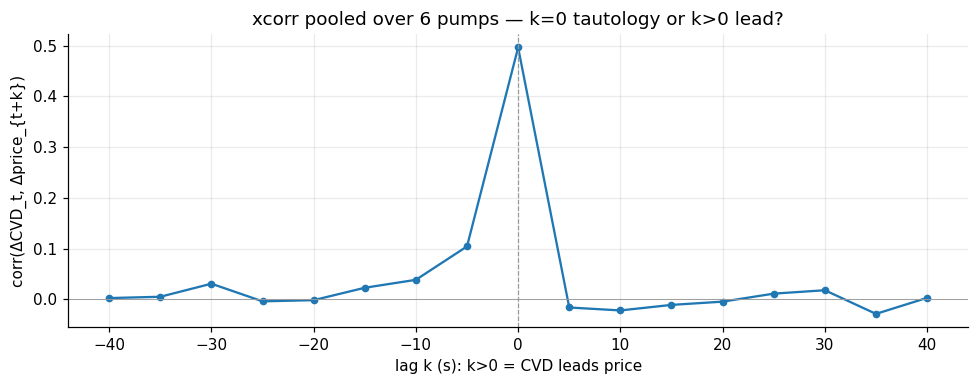

In [2]:
lags = list(range(-8, 9))
def xcorr(df):
    return np.array([df["dcvd"].corr(df["dmid"].shift(-k)) for k in lags])
xc = np.nanmean([xcorr(D[s]) for s in PUMPS], axis=0)
for k, v in zip(lags, xc):
    star = "  <-- k=0" if k == 0 else ""
    print(f"  lag {k*5:+4d}s   {v:+.3f}{star}")

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot([k*5 for k in lags], xc, "-o", ms=4)
ax.axvline(0, color="#999", ls="--", lw=0.8); ax.axhline(0, color="#999", lw=0.6)
ax.set_xlabel("lag k (s): k>0 = CVD leads price"); ax.set_ylabel("corr(ΔCVD_t, Δprice_{t+k})")
ax.set_title("xcorr pooled over 6 pumps — k=0 tautology or k>0 lead?"); show("07_xcorr")

## 2. Bearish divergence → forward return (the real test, no lookahead)

Among price-up moments (trailing 30s > 0): **confirmed** (ΔCVD>0) vs
**divergence** (ΔCVD≤0). 2a = pooled table; **2b = per-symbol gap (the decider)**.

In [3]:
P = pd.concat([D[s] for s in PUMPS], ignore_index=True)
up = P[P["pm"] > 0]
def stat(s):
    return dict(n=len(s), f30_bp=s["f30"].mean(), f120_bp=s["f120"].mean(),
                p_down120=100*(s["f120"] < 0).mean())
tab = pd.DataFrame({
    "baseline (all price-up)": stat(up),
    "confirmed (CVD up)": stat(up[up["pc"] > 0]),
    "divergence (CVD flat/down)": stat(up[up["pc"] <= 0]),
}).T
print("2a. pooled over 6 pumps — forward return after a price-up move (bp):")
print(tab.round(2).to_string())

print("\n2b. per-symbol: confirmed vs divergence f120 (bp) — SIGN MUST AGREE if real")
print(f"    {'sym':11} {'conf':>8} {'div':>8} {'gap(div-conf)':>14}")
for s in PUMPS + REF:
    u = D[s][D[s]["pm"] > 0]
    conf = u[u["pc"] > 0]["f120"].mean(); div = u[u["pc"] <= 0]["f120"].mean()
    tag = "" if s in PUMPS else "  (ref)"
    print(f"    {s:11} {conf:+8.2f} {div:+8.2f} {div-conf:+14.2f}{tag}")

2a. pooled over 6 pumps — forward return after a price-up move (bp):
                                 n  f30_bp  f120_bp  p_down120
baseline (all price-up)     5950.0   -4.34    -8.31      54.39
confirmed (CVD up)          4234.0   -4.10    -6.95      53.42
divergence (CVD flat/down)  1716.0   -4.93   -11.68      56.76

2b. per-symbol: confirmed vs divergence f120 (bp) — SIGN MUST AGREE if real
    sym             conf      div  gap(div-conf)
    EVAAUSDT      -33.20   -55.95         -22.74
    VELVETUSDT    +12.01    -9.64         -21.65
    USUSDT        -21.63   -15.63          +6.00
    SKLUSDT        -0.73    +0.80          +1.53
    LABUSDT        +4.31    +9.92          +5.61
    TACUSDT        -8.57    +0.32          +8.89
    BTCUSDT        -1.69    -0.42          +1.27  (ref)
    SOLUSDT        -3.05    -3.31          -0.26  (ref)


## 3. Reading & verdict\n\n**VERDICT — C is REFUTED. On n=6 pumps the divergence signal does not\ngeneralize; it's carried by the 2 biggest pumps while the other 4 lean the\nopposite way.**\n\n- **§1 — CVD does NOT lead price (robust on n=6).** Pooled xcorr is again a pure\n  **k=0 spike (+0.497)**, flat elsewhere — no k>0 shoulder. The 'CVD tops first'\n  visual is not a systematic lead. Same result as nb06's n=2, now confirmed wide.\n- **§2a pooled** *looks* supportive: divergence f120 −11.7 bp vs confirmed −6.9\n  (all price-up moments fade here, p_down 57% vs 53%). **But §2b kills it:**\n\n  | sym | gap (div−conf) | sign |\n  |---|---|---|\n  | EVAA (+28.9%) | −22.7 | ✓ |\n  | VELVET (+18.4%) | −21.6 | ✓ |\n  | US (+18.1%) | +6.0 | ✗ |\n  | SKL (+16.4%) | +1.5 | ✗ |\n  | LAB (+9.4%) | +5.6 | ✗ |\n  | TAC (+8.9%) | +8.9 | ✗ |\n\n  Only **2 of 6** pumps show the hypothesis sign — and they're the two largest\n  moves, so their big negative gaps dominate the pooled mean. The other 4 (incl.\n  this session's LAB, which was −10.8 in nb06's *different* LAB episode!) go the\n  other way. Refs BTC/SOL ≈ 0, as expected.\n\n**Verdict:** C is dead as a general signal. Across 8 symbols / 2 sessions the\ndivergence→reversal effect refuses to replicate — it's the same 'one or two\nepisodes carry the pool' failure we keep hitting with directional CVD/OI signals\n(nb03, nb06, now nb07). The seductive nb05 heatmap story was, again, an anecdote.\n\n**One noted-but-unchased thread:** the 2 that DID work are the most violent\npumps — 'divergence only bites in extreme moves' is a *possible* refinement, but\n2-for-2 out of 6 is far too thin to chase without many more big-pump episodes,\nand chasing it now would be fishing.\n\n**Caveats:** one afternoon (correlated market — all 6 pumped together), 5s bins\noverlap the forward window, k=0 tautology. But the per-symbol scatter is the\npoint, and it's decisive.